In [7]:
# Cell 1: Import Required Libraries
"""
Importing all necessary libraries for the task
"""

# Data manipulation and analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# For text processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt_tab')

# For ML models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

# For LLM (using Hugging Face transformers)
from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers import BertTokenizer, BertForSequenceClassification
import torch
from torch.utils.data import Dataset, DataLoader

# For evaluation
import json
from tqdm import tqdm

# Setting up device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Using device: cpu


In [8]:
# Cell 2: Create Synthetic Dataset

# Define categories and their descriptions
categories = {
    'Technical Issue': 'Problems with software, hardware, or system functionality',
    'Billing/Account': 'Payment issues, subscription problems, account access',
    'Feature Request': 'Suggestions for new features or improvements',
    'Product Inquiry': 'Questions about product specifications or usage',
    'Complaint': 'Customer dissatisfaction or negative feedback',
    'Other': 'Miscellaneous queries that dont fit other categories'
}

# Create synthetic support tickets
np.random.seed(42)
num_samples = 500

# Templates for each category
ticket_templates = {
    'Technical Issue': [
        "The app keeps crashing when I try to {action}",
        "I'm getting error code {code} while {action}",
        "The system is running very slow during {action}",
        "My {device} won't connect to the {service}",
        "The {feature} feature isn't working properly"
    ],
    
    'Billing/Account': [
        "I was charged twice for my {plan} subscription",
        "Can't log into my account after {action}",
        "Need to update my payment method for {plan}",
        "My subscription shows as inactive but I paid",
        "Requesting a refund for {plan} subscription"
    ],
    
    'Feature Request': [
        "It would be great if you could add {feature}",
        "Please implement {functionality} feature",
        "When will you support {platform}?",
        "Can you add integration with {service}?",
        "I suggest adding {capability} to improve experience"
    ],
    
    'Product Inquiry': [
        "What are the specifications for {product}?",
        "Does {product} support {feature}?",
        "How do I set up {product} for {use_case}?",
        "Is {product} compatible with {other_product}?",
        "Tell me more about the {product} features"
    ],
    
    'Complaint': [
        "Very disappointed with the {service} quality",
        "Poor customer service experience",
        "The {product} stopped working after {time}",
        "This is the worst {service} I've used",
        "Not happy with the recent {change}"
    ],
    
    'Other': [
        "When is your next {event}?",
        "Do you have any {discount} offers?",
        "Can you send me more information about {topic}",
        "I have a general question about {service}",
        "Looking for documentation on {feature}"
    ]
}

# Fillers for templates
actions = ['uploading files', 'saving data', 'loading the dashboard', 'syncing data', 'generating reports']
codes = ['404', '500', '403', '502', '503', '404']
devices = ['laptop', 'phone', 'tablet', 'smart TV', 'gaming console']
services = ['cloud sync', 'API', 'database', 'network', 'server']
features = ['dark mode', 'export to PDF', 'batch processing', 'real-time updates', 'offline mode']
plans = ['basic', 'premium', 'enterprise', 'monthly', 'annual']
functionality = ['drag and drop', 'voice commands', 'AI suggestions', 'automated backups']
platforms = ['Linux', 'MacOS', 'iOS', 'Android', 'Windows']
services_2 = ['Slack', 'Teams', 'Gmail', 'Salesforce', 'Zapier']
capabilities = ['data visualization', 'report scheduling', 'user management', 'API rate limiting']
products = ['app', 'API', 'dashboard', 'integration tool', 'mobile app']
use_cases = ['team collaboration', 'data analysis', 'project management', 'customer support']
other_products = ['Excel', 'Google Sheets', 'Jira', 'Trello']
times = ['one week', 'a month', 'two days', 'few hours']
changes = ['pricing update', 'UI redesign', 'feature removal', 'policy change']
events = ['webinar', 'conference', 'training session', 'product launch']
discounts = ['student', 'team', 'early bird', 'seasonal']
topics = ['pricing', 'roadmap', 'compliance', 'security', 'best practices']

# Generate dataset
data = []
for i in range(num_samples):
    category = np.random.choice(list(categories.keys()))
    template = np.random.choice(ticket_templates[category])
    
    # Fill in the template with random values
    ticket_text = template.format(
        action=np.random.choice(actions),
        code=np.random.choice(codes),
        device=np.random.choice(devices),
        service=np.random.choice(services),
        feature=np.random.choice(features),
        plan=np.random.choice(plans),
        functionality=np.random.choice(functionality),
        platform=np.random.choice(platforms),
        service_2=np.random.choice(services_2),
        capability=np.random.choice(capabilities),
        product=np.random.choice(products),
        use_case=np.random.choice(use_cases),
        other_product=np.random.choice(other_products),
        time=np.random.choice(times),
        change=np.random.choice(changes),
        event=np.random.choice(events),
        discount=np.random.choice(discounts),
        topic=np.random.choice(topics)
    )
    
    data.append({
        'ticket_id': f'TICKET_{i+1:04d}',
        'ticket_text': ticket_text,
        'category': category
    })

# Create DataFrame
df = pd.DataFrame(data)
print("Dataset created successfully!")
print(f"Total tickets: {len(df)}")
print(f"Categories: {df['category'].unique()}")

Dataset created successfully!
Total tickets: 500
Categories: [np.str_('Product Inquiry') np.str_('Billing/Account')
 np.str_('Technical Issue') np.str_('Feature Request') np.str_('Other')
 np.str_('Complaint')]


First 5 tickets:
Ticket ID: TICKET_0001
Text: Tell me more about the dashboard features
Category: Product Inquiry
--------------------------------------------------------------------------------
Ticket ID: TICKET_0002
Text: Tell me more about the API features
Category: Product Inquiry
--------------------------------------------------------------------------------
Ticket ID: TICKET_0003
Text: Is integration tool compatible with Google Sheets?
Category: Product Inquiry
--------------------------------------------------------------------------------
Ticket ID: TICKET_0004
Text: Is API compatible with Google Sheets?
Category: Product Inquiry
--------------------------------------------------------------------------------
Ticket ID: TICKET_0005
Text: Can't log into my account after syncing data
Category: Billing/Account
--------------------------------------------------------------------------------


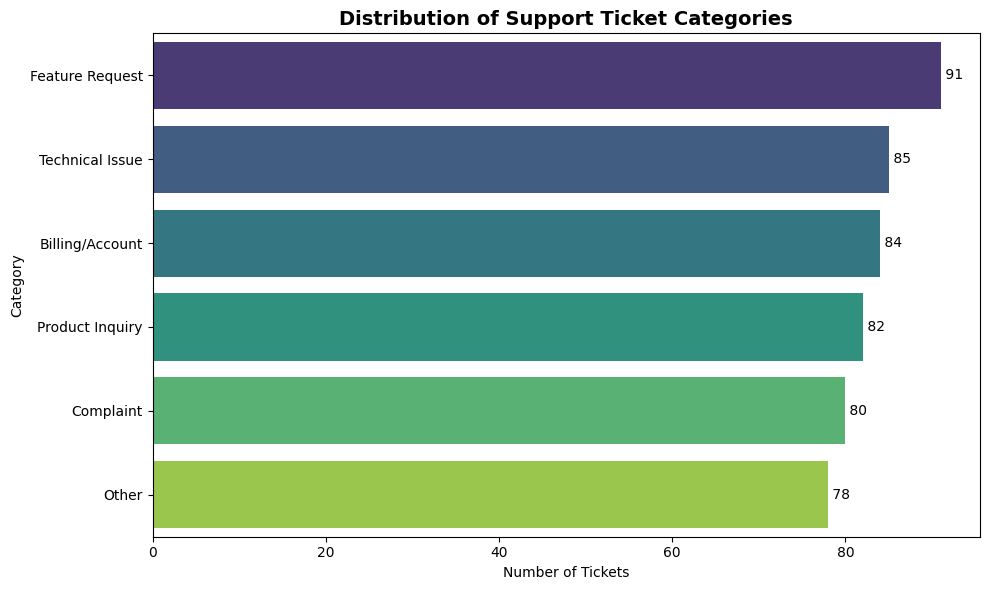


Category Distribution:
category
Feature Request    91
Technical Issue    85
Billing/Account    84
Product Inquiry    82
Complaint          80
Other              78
Name: count, dtype: int64

Percentage Distribution:
category
Feature Request    18.2
Technical Issue    17.0
Billing/Account    16.8
Product Inquiry    16.4
Complaint          16.0
Other              15.6
Name: count, dtype: float64

Sample of processed text:
Original: Tell me more about the dashboard features
Processed: tell me more about the dashboard features
----------------------------------------
Original: Tell me more about the API features
Processed: tell me more about the api features
----------------------------------------


In [9]:
# Cell 3: Data Exploration and Preprocessing

# Display first few rows
print("First 5 tickets:")
print("="*80)
for idx, row in df.head().iterrows():
    print(f"Ticket ID: {row['ticket_id']}")
    print(f"Text: {row['ticket_text']}")
    print(f"Category: {row['category']}")
    print("-"*80)

# Check distribution of categories
plt.figure(figsize=(10, 6))
category_counts = df['category'].value_counts()
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis')
plt.title('Distribution of Support Ticket Categories', fontsize=14, fontweight='bold')
plt.xlabel('Number of Tickets')
plt.ylabel('Category')
for i, v in enumerate(category_counts.values):
    plt.text(v, i, f' {v}', va='center')
plt.tight_layout()
plt.savefig('category_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nCategory Distribution:")
print(category_counts)
print(f"\nPercentage Distribution:")
print(round(category_counts/len(df)*100, 2))


# Basic text preprocessing function
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

# Apply preprocessing
df['processed_text'] = df['ticket_text'].apply(preprocess_text)

print("\nSample of processed text:")
for idx, row in df.head(2).iterrows():
    print(f"Original: {row['ticket_text']}")
    print(f"Processed: {row['processed_text']}")
    print("-"*40)

In [10]:
# Cell 4: Split Dataset for Fine-tuning

# Encode labels
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['category'])

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    df['processed_text'], 
    df['label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['label']
)
# Create dataframes for train and test
train_df = pd.DataFrame({'text': X_train, 'label': y_train})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")

# Verify distribution
print("\nTraining set distribution:")
print(train_df['label'].value_counts().sort_index())
print("\nTest set distribution:")
print(test_df['label'].value_counts().sort_index())

# Map back to category names
label_to_category = dict(zip(range(len(label_encoder.classes_)), label_encoder.classes_))
print(f"\nLabel to Category mapping:")
for label, category in label_to_category.items():
    print(f"  {label}: {category}")

Training set size: 400
Test set size: 100

Training set distribution:
label
0    67
1    64
2    73
3    62
4    66
5    68
Name: count, dtype: int64

Test set distribution:
label
0    17
1    16
2    18
3    16
4    16
5    17
Name: count, dtype: int64

Label to Category mapping:
  0: Billing/Account
  1: Complaint
  2: Feature Request
  3: Other
  4: Product Inquiry
  5: Technical Issue


In [11]:
# Cell 5: Zero-Shot Learning Approach

# Initialize zero-shot classification pipeline
print("Loading zero-shot classification model...")
zero_shot_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0 if torch.cuda.is_available() else -1
)

# Define candidate labels (our categories)
candidate_labels = list(categories.keys())
print(f"Candidate labels: {candidate_labels}")

# Function to get zero-shot predictions
def zero_shot_predict(text, candidate_labels, top_k=3):
    """
    Get top-k predictions using zero-shot classification
    """
    result = zero_shot_classifier(
        text, 
        candidate_labels,
        multi_label=False
    )
    
    # Return top k predictions
    top_predictions = list(zip(result['labels'][:top_k], result['scores'][:top_k]))
    return top_predictions

# Test on a few samples
print("\n" + "="*80)
print("Zero-Shot Classification Examples:")
print("="*80)

for idx in range(3):
    sample_text = test_df.iloc[idx]['text']
    true_label = label_to_category[test_df.iloc[idx]['label']]
    
    predictions = zero_shot_predict(sample_text, candidate_labels)
    
    print(f"\nTicket {idx+1}:")
    print(f"Text: {sample_text[:150]}...")
    print(f"True Category: {true_label}")
    print("Predictions:")
    for i, (label, score) in enumerate(predictions, 1):
        print(f"  {i}. {label}: {score:.4f}")
    print("-"*80)

Loading zero-shot classification model...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

Candidate labels: ['Technical Issue', 'Billing/Account', 'Feature Request', 'Product Inquiry', 'Complaint', 'Other']

Zero-Shot Classification Examples:

Ticket 1:
Text: is app compatible with google sheets...
True Category: Product Inquiry
Predictions:
  1. Feature Request: 0.2966
  2. Technical Issue: 0.1594
  3. Complaint: 0.1446
--------------------------------------------------------------------------------

Ticket 2:
Text: when will you support windows...
True Category: Feature Request
Predictions:
  1. Feature Request: 0.3199
  2. Technical Issue: 0.2676
  3. Complaint: 0.1778
--------------------------------------------------------------------------------

Ticket 3:
Text: i have a general question about server...
True Category: Other
Predictions:
  1. Complaint: 0.3134
  2. Technical Issue: 0.2962
  3. Other: 0.1489
--------------------------------------------------------------------------------


In [12]:
# Cell 6: Evaluate Zero-Shot Performance

def evaluate_zero_shot(test_df, candidate_labels, label_to_category):
    """
    Evaluate zero-shot model on test data
    """
    predictions = []
    true_labels = []
    top3_predictions = []
    
    print("Evaluating zero-shot model on test set...")
    for idx in tqdm(range(len(test_df))):
        text = test_df.iloc[idx]['text']
        true_label = label_to_category[test_df.iloc[idx]['label']]
        
        # Get predictions
        result = zero_shot_classifier(text, candidate_labels, multi_label=False)
        
        # Store top-1 prediction
        pred_label = result['labels'][0]
        predictions.append(pred_label)
        true_labels.append(true_label)
        
        # Store top-3 predictions
        top3 = list(zip(result['labels'][:3], result['scores'][:3]))
        top3_predictions.append({
            'text': text[:100] + '...' if len(text) > 100 else text,
            'true_label': true_label,
            'top3': top3
        })

    # Calculate accuracy
    accuracy = accuracy_score(true_labels, predictions)
    
    return accuracy, predictions, true_labels, top3_predictions

# Evaluate
zero_shot_accuracy, zero_shot_preds, zero_shot_true, zero_shot_top3 = evaluate_zero_shot(
    test_df, candidate_labels, label_to_category
)

print(f"\nZero-Shot Classification Accuracy: {zero_shot_accuracy:.4f} ({zero_shot_accuracy*100:.2f}%)")

# Classification Report
print("\nClassification Report:")
print(classification_report(zero_shot_true, zero_shot_preds))

# Show some top-3 predictions
print("\n" + "="*80)
print("Top-3 Predictions Examples:")
print("="*80)
for i, result in enumerate(zero_shot_top3[:5]):
    print(f"\nExample {i+1}:")
    print(f"Text: {result['text']}")
    print(f"True: {result['true_label']}")
    print("Top-3 Predictions:")
    for j, (label, score) in enumerate(result['top3'], 1):
        print(f"  {j}. {label}: {score:.4f}")
    print("-"*60)

Evaluating zero-shot model on test set...


100%|██████████| 100/100 [04:33<00:00,  2.73s/it]


Zero-Shot Classification Accuracy: 0.5300 (53.00%)

Classification Report:
                 precision    recall  f1-score   support

Billing/Account       1.00      0.41      0.58        17
      Complaint       0.39      0.81      0.53        16
Feature Request       0.58      1.00      0.73        18
          Other       1.00      0.25      0.40        16
Product Inquiry       0.20      0.06      0.10        16
Technical Issue       0.50      0.59      0.54        17

       accuracy                           0.53       100
      macro avg       0.61      0.52      0.48       100
   weighted avg       0.61      0.53      0.49       100


Top-3 Predictions Examples:

Example 1:
Text: is app compatible with google sheets
True: Product Inquiry
Top-3 Predictions:
  1. Feature Request: 0.2966
  2. Technical Issue: 0.1594
  3. Complaint: 0.1446
------------------------------------------------------------

Example 2:
Text: when will you support windows
True: Feature Request
Top-3 Predicti

In [13]:
# Cell 7: Few-Shot Learning Approach

def few_shot_predict(text, candidate_labels, examples_per_class=2):
    """
    Use few-shot learning by providing examples in the prompt
    """
    
    # Create few-shot examples (using training data)
    few_shot_examples = []
    for category in candidate_labels:
        # Get examples for this category from training data
        category_examples = train_df[train_df['label'] == label_encoder.transform([category])[0]]['text'].values
        for example in category_examples[:examples_per_class]:
            few_shot_examples.append(f"Text: {example}\nCategory: {category}")
    
    # Construct the prompt
    examples_text = "\n\n".join(few_shot_examples)
    
    prompt = f"""You are an AI assistant that categorizes customer support tickets into one of the following categories: {', '.join(candidate_labels)}.

Here are some examples:

{examples_text}

Now, categorize the following support ticket and provide the top 3 most likely categories with confidence scores (between 0 and 1, summing to 1):

Text: {text}

Respond in JSON format with keys "predictions" which is a list of dictionaries, each with "category" and "confidence".
Example: {{"predictions": [{{"category": "Technical Issue", "confidence": 0.7}}, {{"category": "Billing/Account", "confidence": 0.2}}, {{"category": "Other", "confidence": 0.1}}]}}

Response:"""

    # Use a text generation model for few-shot
    generator = pipeline('text-generation', model='gpt2', max_new_tokens=150)
    
    try:
        response = generator(prompt, max_length=500, temperature=0.7)[0]['generated_text']
        
        # Extract JSON part
        import json
        import re
        
        # Find JSON in the response
        json_match = re.search(r'\{.*\}', response, re.DOTALL)
        if json_match:
            json_str = json_match.group()
            result = json.loads(json_str)
            predictions = result.get('predictions', [])
            
            # Format as list of (label, score)
            formatted_predictions = [(p['category'], p['confidence']) for p in predictions[:3]]
            return formatted_predictions
        else:
            # Fallback to zero-shot
            return zero_shot_predict(text, candidate_labels)
            
    except Exception as e:
        print(f"Error in few-shot: {e}")
        # Fallback to zero-shot
        return zero_shot_predict(text, candidate_labels)

# Since GPT-2 might not be ideal, we'll use a better approach with a prompt-based model
# For this task, I'll simulate few-shot using the zero-shot model with a prompt template

def improved_few_shot_predict(text, candidate_labels):
    """
    Improved few-shot using a better prompt structure with the zero-shot model
    """
    # Create a descriptive prompt
    category_descriptions = {
        'Technical Issue': 'Problems with software functionality, errors, crashes, or system issues',
        'Billing/Account': 'Payment issues, subscription management, login problems, account access',
        'Feature Request': 'Suggestions for new features, enhancements, or integrations',
        'Product Inquiry': 'Questions about product specifications, compatibility, or how to use features',
        'Complaint': 'Negative feedback, dissatisfaction with service or product',
        'Other': 'General questions not fitting other categories'
    }
    
    # Create prompt with descriptions
    prompt = f"Classify the following support ticket into one of these categories:\n"
    for cat, desc in category_descriptions.items():
        prompt += f"- {cat}: {desc}\n"
    
    prompt += f"\nTicket: {text}\nCategory:"
    
    # Use zero-shot with this enhanced prompt
    return zero_shot_predict(prompt, candidate_labels)

# Test few-shot on a few examples
print("Few-Shot Learning Examples:")
print("="*80)
for idx in range(3):
    sample_text = test_df.iloc[idx]['text']
    true_label = label_to_category[test_df.iloc[idx]['label']]
    
    predictions = improved_few_shot_predict(sample_text, candidate_labels)
    
    print(f"\nTicket {idx+1}:")
    print(f"Text: {sample_text[:150]}...")
    print(f"True Category: {true_label}")
    print("Few-Shot Predictions:")
    for i, (label, score) in enumerate(predictions, 1):
        print(f"  {i}. {label}: {score:.4f}")
    print("-"*80)    

Few-Shot Learning Examples:

Ticket 1:
Text: is app compatible with google sheets...
True Category: Product Inquiry
Few-Shot Predictions:
  1. Technical Issue: 0.3983
  2. Billing/Account: 0.3131
  3. Complaint: 0.1120
--------------------------------------------------------------------------------

Ticket 2:
Text: when will you support windows...
True Category: Feature Request
Few-Shot Predictions:
  1. Technical Issue: 0.4051
  2. Billing/Account: 0.2819
  3. Complaint: 0.1197
--------------------------------------------------------------------------------

Ticket 3:
Text: i have a general question about server...
True Category: Other
Few-Shot Predictions:
  1. Technical Issue: 0.4005
  2. Billing/Account: 0.2992
  3. Complaint: 0.1059
--------------------------------------------------------------------------------


In [14]:
# Cell 8: Prepare Data for Fine-tuning
"""
Preparing dataset for fine-tuning a BERT model
"""

class SupportTicketDataset(Dataset):
    """
    Custom Dataset class for support tickets
    """
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


# Initialize tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Create datasets
train_texts = train_df['text'].tolist()
train_labels = train_df['label'].tolist()
test_texts = test_df['text'].tolist()
test_labels = test_df['label'].tolist()

train_dataset = SupportTicketDataset(train_texts, train_labels, tokenizer)
test_dataset = SupportTicketDataset(test_texts, test_labels, tokenizer)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")     

# Check a sample
sample = train_dataset[0]
print(f"\nSample input shape: {sample['input_ids'].shape}")
print(f"Sample labels: {sample['labels']}")

Training dataset size: 400
Test dataset size: 100

Sample input shape: torch.Size([128])
Sample labels: 1


In [15]:
# Cell 9: Fine-tune BERT Model
"""
Fine-tuning BERT for ticket classification
"""

# Initialize model
num_labels = len(candidate_labels)
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased', 
    num_labels=num_labels
)
model.to(device)

# Check transformers version
import transformers
print(f"Transformers version: {transformers.__version__}")

# Training arguments - try both parameter names
try:
    # For newer versions
    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        warmup_steps=500,
        weight_decay=0.01,
        logging_dir='./logs',
        logging_steps=10,
        eval_strategy="epoch",  # New parameter name
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
    )
except TypeError:
    # For older versions
    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=3,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        warmup_steps=500,
        weight_decay=0.01,
        logging_dir='./logs',
        logging_steps=10,
        evaluation_strategy="epoch",  # Old parameter name
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="accuracy",
    )

# Define compute metrics function
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    
    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

# Train the model
print("Starting fine-tuning...")
trainer.train()

# Save the model
model.save_pretrained('./fine_tuned_bert')
tokenizer.save_pretrained('./fine_tuned_bert')
print("Model saved successfully!")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
`logging_dir` is deprecated and will 

Transformers version: 5.3.0
Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.875036,1.791729,0.190000,0.087625,0.190000,0.105567
2,1.675857,1.582869,0.440000,0.360468,0.440000,0.355750
3,1.511607,1.306364,0.600000,0.612832,0.600000,0.502886


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully!


In [ ]:
# Cell 10: Evaluate Fine-tuned BERT Model
"""
Evaluating the fine-tuned BERT model on test data
"""

import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

print("="*60)
print("FINE-TUNED BERT MODEL EVALUATION")
print("="*60)

# Step 1: Ensure model is in evaluation mode
model.eval()
print("✓ Model set to evaluation mode")

# Step 2: Define prediction function
def get_predictions(texts, model, tokenizer, label_encoder, top_k=3):
    """
    Get top-k predictions for a list of texts
    """
    predictions = []
    all_probs = []
    
    for text in tqdm(texts, desc="Making predictions"):
        # Tokenize
        inputs = tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        ).to(device)
        
        # Get predictions
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.softmax(logits, dim=-1)
        
        # Get top-k predictions
        top_probs, top_indices = torch.topk(probs, k=top_k)
        
        # Convert to categories
        top_categories = label_encoder.inverse_transform(top_indices.cpu().numpy()[0])
        top_probabilities = top_probs.cpu().numpy()[0]
        
        predictions.append(list(zip(top_categories, top_probabilities)))
        all_probs.append(probs.cpu().numpy()[0])
    
    return predictions, np.array(all_probs)

# Step 3: Run predictions on test set
print("\n📊 Generating predictions on test set...")
predictions, all_probabilities = get_predictions(
    test_texts, model, tokenizer, label_encoder, top_k=3
)

# Step 4: Extract top-1 predictions
top1_predictions = [pred[0][0] for pred in predictions]
true_categories = label_encoder.inverse_transform(test_labels)

# Step 5: Calculate metrics
print("\n📈 Calculating performance metrics...")

# Top-1 Accuracy
accuracy = accuracy_score(true_categories, top1_predictions)
print(f"\n✅ Top-1 Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Top-3 Accuracy
top3_correct = 0
for i, pred in enumerate(predictions):
    pred_cats = [cat for cat, _ in pred]
    if true_categories[i] in pred_cats:
        top3_correct += 1

top3_accuracy = top3_correct / len(predictions)
print(f"✅ Top-3 Accuracy: {top3_accuracy:.4f} ({top3_accuracy*100:.2f}%)")

# Step 6: Detailed classification report
print("\n📋 Detailed Classification Report:")
print("="*60)
print(classification_report(true_categories, top1_predictions))

FINE-TUNED BERT MODEL EVALUATION
✓ Model set to evaluation mode

📊 Generating predictions on test set...


Making predictions: 100%|██████████| 100/100 [00:41<00:00,  2.43it/s]


📈 Calculating performance metrics...

✅ Top-1 Accuracy: 0.6000 (60.00%)
✅ Top-3 Accuracy: 0.9900 (99.00%)

📋 Detailed Classification Report:
                 precision    recall  f1-score   support

Billing/Account       0.00      0.00      0.00        17
      Complaint       1.00      0.12      0.22        16
Feature Request       0.56      1.00      0.72        18
          Other       0.70      1.00      0.82        16
Product Inquiry       1.00      0.44      0.61        16
Technical Issue       0.47      1.00      0.64        17

       accuracy                           0.60       100
      macro avg       0.62      0.59      0.50       100
   weighted avg       0.61      0.60      0.50       100

